<a href="https://colab.research.google.com/github/engcriscunha/avanti-bean-leaf-classification/blob/main/execu%C3%A7%C3%A3o_notebook_akhilchibber.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Execução do notebook

https://www.kaggle.com/code/akhilchibber/bean-leaf-lesions-classification#The-Dataset

### 1. Baixar o Dataset do Kaggle

In [ ]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.6 MB/s eta 0:00:00


In [ ]:
import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eng.criscunha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:01<00:00, 98.3MB/s]


In [ ]:
!ls

bean-leaf-lesions-classification  sample_data


In [ ]:
import cv2
import os

In [ ]:
root_dir = './bean-leaf-lesions-classification'

In [ ]:
# estrutura do data set

print(os.listdir("./bean-leaf-lesions-classification"))

['train.csv', 'classname.txt', 'val', 'train', 'val.csv']


# **1.1 Importação das Bibliotecas**

Começamos importando as bibliotecas necessárias do Python. Essas bibliotecas nos auxiliam na manipulação de dados (pandas e numpy), no processamento e manipulação de imagens (PIL e matplotlib), entre outras funcionalidades importantes para a análise e o desenvolvimento do projeto.

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from glob import glob

### **1.2 Carregamento e Organização dos Dados**

Nesta etapa, carregamos as imagens e seus respectivos rótulos (labels). O conjunto de dados é composto por imagens organizadas em diferentes pastas, sendo que cada pasta representa uma classe específica da doença ou condição da planta, como saudável (healthy), mancha angular da folha (angular_leaf_spot) e ferrugem do feijão (bean_rust). Essa organização facilita a identificação das classes e o treinamento do modelo de aprendizado de máquina.

In [ ]:
# Create dataframes to hold paths and labels
train_df = pd.DataFrame({"path":[], "label":[], "class_id":[]})
val_df = pd.DataFrame({"path":[], "label":[], "class_id":[]})

In [ ]:
# Define the path to the training and validation data
train_path = "./bean-leaf-lesions-classification/train"
val_path = "./bean-leaf-lesions-classification/val"

In [ ]:
# Define a dictionary to map labels to numeric ids
label_dict = {"healthy": 0, "angular_leaf_spot": 1, "bean_rust": 2}

In [ ]:
# Function to load images and labels into the dataframe
def load_images(path, label_dict):
    df = pd.DataFrame({"path":[], "label":[], "class_id":[]})
    folder_list = os.listdir(path)
    for folder in folder_list:
        img_path = os.path.join(path, folder)
        jpg_list = glob(img_path + '/*.jpg')
        for jpg in jpg_list:
            new_data = pd.DataFrame({"path": [jpg], "label": [folder], "class_id": [label_dict[folder]]})
            df = pd.concat([df, new_data], ignore_index=True)
    return df

In [ ]:
# Load training and validation data
train_df = load_images(train_path, label_dict)
val_df = load_images(val_path, label_dict)

### **1.3 Visualização dos Dados**

É uma boa prática visualizar parte do conjunto de dados antes de iniciar o treinamento do modelo. Nesta etapa, selecionamos aleatoriamente algumas imagens do conjunto de treinamento e as exibimos para verificar sua qualidade, diversidade e se os rótulos (classes) estão corretamente associados às imagens. Essa inspeção inicial ajuda a identificar possíveis problemas, como imagens corrompidas, baixa qualidade ou erros de classificação, contribuindo para a construção de um modelo mais confiável.

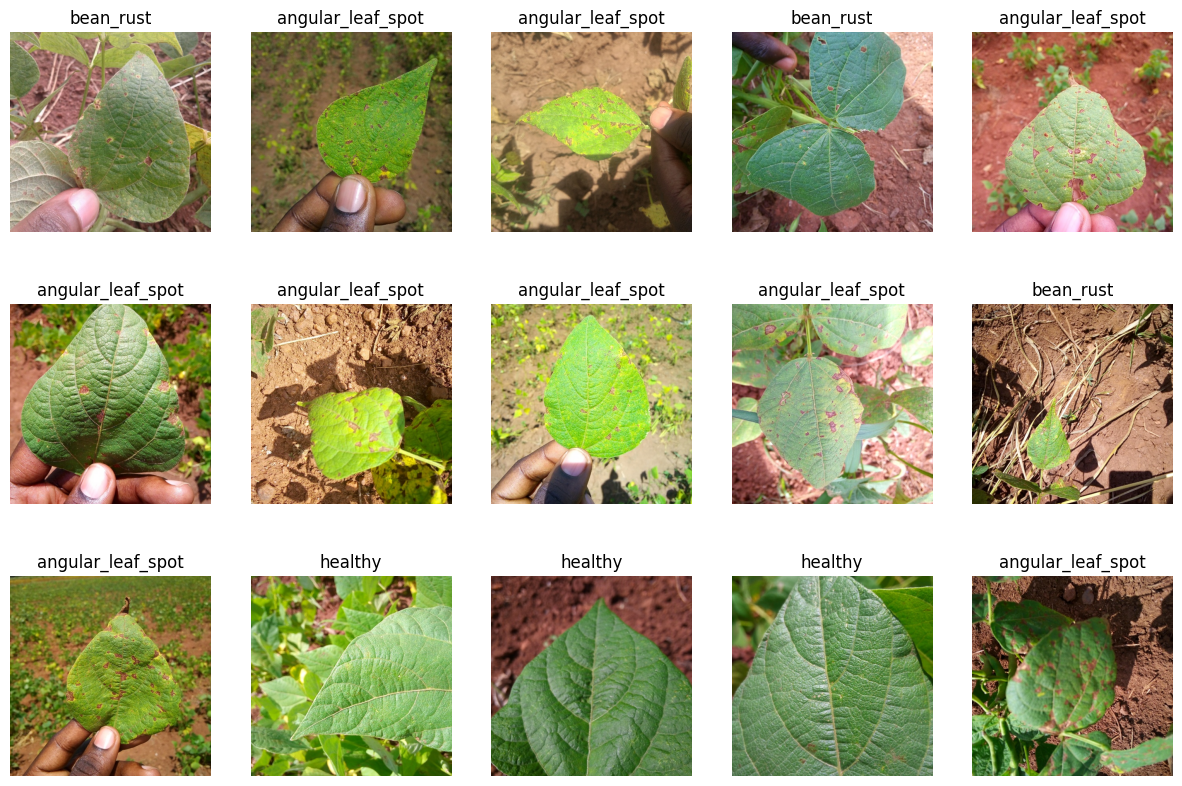

In [ ]:
show_imgs = 15
idx = np.random.randint(0, len(train_df), size=show_imgs)
fig, axes = plt.subplots(show_imgs // 5, 5, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    full_path = train_df.loc[idx[i]]['path']
    ax.imshow(plt.imread(full_path))
    ax.set_title(train_df.loc[idx[i]]['label'])
    ax.set_axis_off()

plt.show()

### **1.4 Transformação e Aumento de Dados**

Usaremos as transformações (transforms) do PyTorch para pré-processar e aumentar as imagens. Esta etapa é crucial para que os modelos de aprendizado profundo generalizem melhor.

In [ ]:
# Data Transformation and Augmentation
import torchvision.transforms as transforms

# Define transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    # Other transformations can be added here
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### **1.5 Criar um Conjunto de Dados Personalizado**

Criamos uma classe de conjunto de dados personalizada que estende a classe Dataset do PyTorch. Essa classe será responsável por carregar as imagens e aplicar as transformações.

In [ ]:
# Create Custom Dataset
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, dataframe, transforms_):
        self.df = dataframe
        self.transforms_ = transforms_

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        image_path = self.df.iloc[index]['path']
        img = Image.open(image_path).convert("RGB")
        transformed_img = self.transforms_(img)
        class_id = self.df.iloc[index]['class_id']
        return transformed_img, class_id

### **1.6 Criar DataLoaders**

Por fim, configuramos os DataLoaders do PyTorch para os conjuntos de dados de treinamento e validação. Os DataLoaders permitem o carregamento eficiente e o processamento em lotes (batches) dos dados durante o treinamento.

In [ ]:
# Create DataLoaders
from torch.utils.data import DataLoader

train_dataset = MyDataset(train_df, train_transforms)
val_dataset = MyDataset(val_df, val_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

Isso conclui a etapa de Preparação dos Dados. Em seguida, passaremos para a construção do modelo.

# **Step 2: Construção do Modelo**

Nesta seção, vamos nos concentrar na configuração do modelo de aprendizado profundo. Ela aborda a parte do código em que o modelo de rede neural é carregado (utilizando os modelos pré-treinados do PyTorch) e modificado para a tarefa específica de classificação. Isso inclui a criação da classe MyDataset e a modificação da camada classificadora (classifier) do modelo.

### **2.1 Importar as Bibliotecas Necessárias**

Primeiro, precisamos importar os componentes necessários do PyTorch.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

### **2.2 Definir o Modelo**

Utilizaremos um modelo pré-treinado e modificaremos sua camada final para adequá-lo à nossa tarefa de classificação, que possui três classes (healthy, angular_leaf_spot e bean_rust).

In [ ]:
# Define the number of classes
num_classes = 3

# Load a pre-trained model
model = models.efficientnet_v2_s(pretrained=True)

# Modify the classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Print the Deep Learning model architecture
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 101MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

### **2.3 Definir o Dispositivo**

Precisamos definir o dispositivo como CPU ou GPU (se disponível) para realizar o treinamento.

In [ ]:
# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the chosen device
model = model.to(device)

### **2.4 Print Model Summary**


In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary

# Print the model summary (for input size [3, 224, 224])
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]               0
           Conv2d-14           [-1, 96,

Conclusão da Construção do Modelo

Isso conclui a etapa de construção do modelo. Carregamos com sucesso um modelo EfficientNet pré-treinado e o adaptamos para nossa tarefa de classificação com três classes. O modelo agora está pronto para ser treinado utilizando o conjunto de dados de lesões em folhas de feijão.

# **Etapa 3: Treinamento e Validação do Modelo**

Esta etapa abrange o loop de treinamento e as funções necessárias para o treinamento (train) e a validação (test). Serão detalhadas as etapas do processo de treinamento, incluindo a configuração da função de perda (loss function), do otimizador (optimizer), do agendador da taxa de aprendizado (learning rate scheduler) e do próprio loop de treinamento, que inclui o mecanismo de parada antecipada (early stopping).

### **3.1 Importar as Bibliotecas Necessárias**

Primeiro, precisamos garantir que todas as bibliotecas necessárias estejam importadas.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from tqdm import tqdm

### **3.2 Definir a Função de Perda, o Otimizador e o Agendador da Taxa de Aprendizado**

Antes de iniciar o treinamento, definimos a função de perda (loss function), o otimizador (optimizer) e o agendador da taxa de aprendizado (learning rate scheduler).

In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (using AdamW here)
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Learning rate scheduler (optional)
lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

### **3.3 Funções de Treinamento e Validação**

Defina as funções responsáveis pelo treinamento e pela validação do modelo.

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device).long()

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save the metrics as Python numbers
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())  # Convert to Python number
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())  # Convert to Python number

    print('Training complete')

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

### **3.4 Treinar o Modelo**

Agora, utilizamos as funções definidas para treinar e validar o nosso modelo. Defina o número de épocas (epochs) de acordo com a necessidade do treinamento.

In [ ]:
model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(model, criterion, optimizer, lr_scheduler, num_epochs=25)

Epoch 1/25
----------
train Loss: 0.8143 Acc: 0.6712
val Loss: 0.3417 Acc: 0.9323
Epoch 2/25
----------
train Loss: 0.3071 Acc: 0.9033
val Loss: 0.1402 Acc: 0.9549
Epoch 3/25
----------
train Loss: 0.1976 Acc: 0.9362
val Loss: 0.1108 Acc: 0.9699
Epoch 4/25
----------
train Loss: 0.1372 Acc: 0.9487
val Loss: 0.0860 Acc: 0.9699
Epoch 5/25
----------
train Loss: 0.1492 Acc: 0.9478
val Loss: 0.0381 Acc: 0.9925
Epoch 6/25
----------
train Loss: 0.0952 Acc: 0.9681
val Loss: 0.0439 Acc: 0.9850
Epoch 7/25
----------
train Loss: 0.1128 Acc: 0.9603
val Loss: 0.0683 Acc: 0.9774
Epoch 8/25
----------
train Loss: 0.0880 Acc: 0.9691
val Loss: 0.0568 Acc: 0.9850
Epoch 9/25
----------
train Loss: 0.0872 Acc: 0.9691
val Loss: 0.0756 Acc: 0.9774
Epoch 10/25
----------
train Loss: 0.0895 Acc: 0.9662
val Loss: 0.0501 Acc: 0.9850
Epoch 11/25
----------
train Loss: 0.0885 Acc: 0.9710
val Loss: 0.0742 Acc: 0.9774
Epoch 12/25
----------
train Loss: 0.0815 Acc: 0.9739
val Loss: 0.0630 Acc: 0.9850
Epoch 13/25
-

In [ ]:
# Save the model
torch.save(model.state_dict(), "./bean-leaf-lesions-classification/model.pth")

### **3.5 Plotagem das Métricas**

Após o treinamento, utilizaremos o Matplotlib para gerar gráficos da perda (loss) e da acurácia (accuracy) durante o treinamento do modelo. Esses gráficos permitem visualizar o desempenho do modelo ao longo das épocas e avaliar sua evolução durante o processo de aprendizagem.

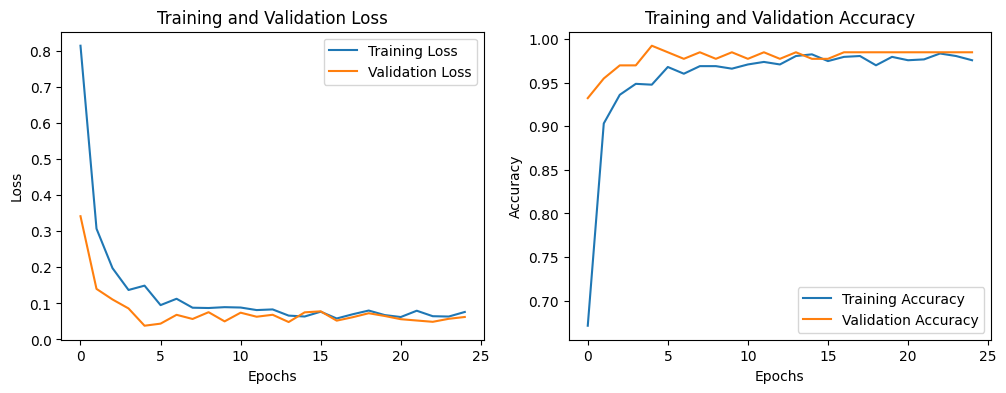

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_acc_history, label='Training Accuracy')
plt.plot(val_acc_history, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Conclusão do Treinamento e Validação do Modelo

Isso conclui a etapa de Treinamento e Validação do Modelo. Nesta fase, treinamos o modelo utilizando o conjunto de dados de treinamento e avaliamos seu desempenho no conjunto de validação. Os pesos do modelo foram atualizados para aprender com os dados de treinamento, enquanto sua acurácia (accuracy) e perda (loss) foram monitoradas para garantir um aprendizado adequado.

Na Etapa 4, avaliaremos com mais detalhes o desempenho do modelo treinado, especialmente em relação ao conjunto de validação.

# **Etapa 4: Avaliação do Modelo**

Nesta etapa, vamos nos concentrar no carregamento do melhor modelo e na avaliação de seu desempenho utilizando o conjunto de dados de validação. Esta parte aborda as seções do código em que o modelo é carregado a partir do estado salvo (best.pth) e seu desempenho é avaliado por meio do conjunto de validação.

### **4.1 Avaliar o Modelo**

Primeiro, criaremos uma função para avaliar o modelo. Essa função utilizará o conjunto de dados de validação para prever os rótulos (labels) e, em seguida, compará-los com os rótulos verdadeiros.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

def evaluate_model(model, dataloader):
    model.eval()  # Set the model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad():  # No need to track the gradients
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Evaluate the model
all_labels, all_preds = evaluate_model(model, val_loader)

### **4.2 Relatório de Classificação e Acurácia**

Em seguida, geraremos um relatório de classificação (classification report) e calcularemos a acurácia (accuracy) do modelo.

In [ ]:
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["healthy", "angular_leaf_spot", "bean_rust"]))

accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy: {accuracy * 100:.2f}%")

Classification Report:
                   precision    recall  f1-score   support

          healthy       0.98      1.00      0.99        44
angular_leaf_spot       1.00      0.95      0.98        44
        bean_rust       0.98      1.00      0.99        45

         accuracy                           0.98       133
        macro avg       0.99      0.98      0.98       133
     weighted avg       0.99      0.98      0.98       133

Accuracy: 98.50%


Esta etapa fornece uma visão detalhada do desempenho do modelo no conjunto de validação, destacando seus pontos fortes e os aspectos que podem necessitar de melhorias. O relatório de classificação (classification report) apresenta uma visão abrangente da precisão (precision), da revocação (recall) e da pontuação F1 (F1-score) para cada classe, enquanto a matriz de confusão (confusion matrix) representa visualmente as previsões do modelo em comparação com os rótulos reais.

### **4.33 Matriz de Confusão**

Visualize o desempenho do modelo por meio de uma matriz de confusão (confusion matrix). Essa ferramenta permite comparar as classes previstas pelo modelo com as classes reais, facilitando a identificação de acertos e erros de classificação para cada classe do conjunto de dados.

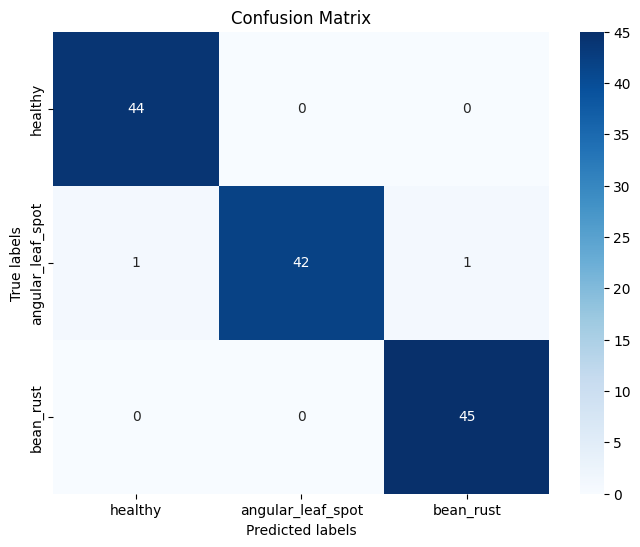

In [ ]:
# Generate a confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=["healthy", "angular_leaf_spot", "bean_rust"], yticklabels=["healthy", "angular_leaf_spot", "bean_rust"])
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show()

Conclusão da Etapa 4: Avaliação do Modelo

Isso conclui a Etapa 4: Avaliação do Modelo, na qual avaliamos o desempenho do nosso modelo de aprendizado profundo treinado. Ao utilizar métricas como o relatório de classificação (classification report), a acurácia (accuracy) e a matriz de confusão (confusion matrix), obtivemos informações valiosas sobre o quão bem o modelo prediz cada classe e em quais situações ele pode estar cometendo erros.

Agora, passamos para a etapa final, a Etapa 5: Resultados e Visualização. Nesta etapa, nosso foco será a visualização dos resultados obtidos durante o treinamento e a avaliação do modelo. Isso inclui a geração de gráficos das curvas de perda (loss) e acurácia (accuracy) para os conjuntos de treinamento e validação ao longo das épocas, além da apresentação de quaisquer outros insights obtidos a partir do desempenho do modelo no conjunto de validação.

Essa etapa é fundamental para compreender a eficácia geral do modelo e comunicar os resultados de forma clara e facilmente interpretável.

# **Etapa 5: Resultados e Visualização**

Por fim, esta etapa trata da visualização dos resultados do treinamento e do desempenho do modelo. Ela inclui a geração de gráficos das perdas (loss) e das acurácias (accuracy) dos conjuntos de treinamento e validação, a exibição da matriz de confusão (confusion matrix) e a apresentação do relatório de classificação (classification report).

### **5.1 Exibir uma Predição Correta**

Em seguida, vamos visualizar um exemplo do conjunto de dados de validação em que o modelo realizou uma predição correta. Para isso, exibiremos a imagem, o rótulo verdadeiro (true label) e o rótulo previsto (predicted label).

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def visualize_multiple_predictions(dataloader, model, device, num_images=15):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(15, 15))  # Increased figure size for better spacing

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probabilities = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            for i in range(inputs.shape[0]):
                if images_shown == num_images:
                    break

                confidence = torch.max(probabilities[i]).item() * 100  # Convert to percentage
                img = inputs[i].cpu().data.numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)

                ax = plt.subplot(num_images // 5, 5, images_shown + 1)
                ax.imshow(img)
                ax.set_title(f'Prediction: {preds[i].item()}, Ground Truth: {labels[i].item()}\nConfidence: {confidence:.2f}%', fontsize=10)
                ax.axis('off')

                images_shown += 1

            if images_shown == num_images:
                break

    plt.subplots_adjust(hspace=0.03)  # Adjust horizontal space
    plt.show()

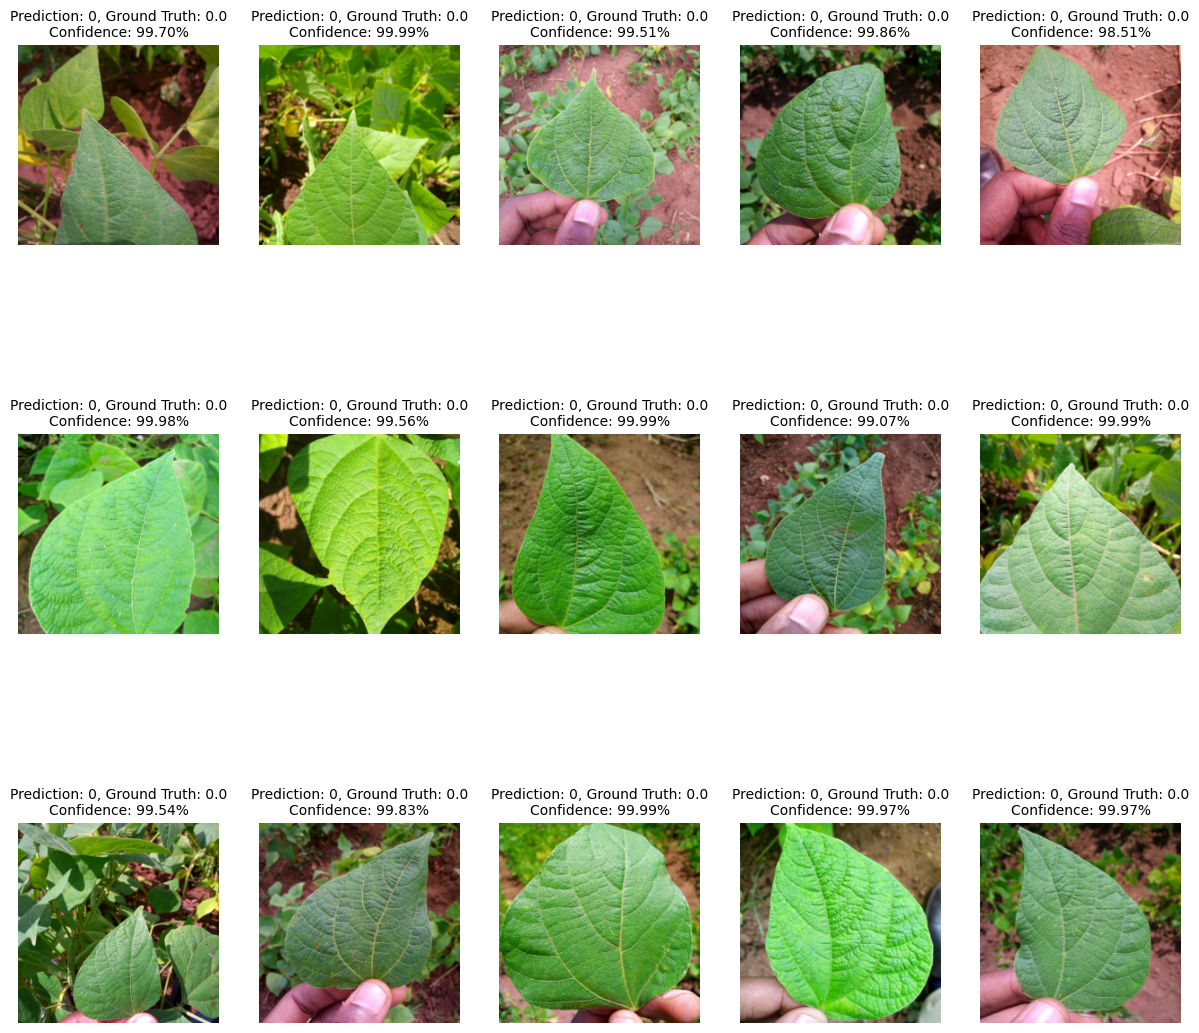

In [ ]:
# Call the function to visualize predictions
visualize_multiple_predictions(val_loader, model, device, num_images=15)

# **Conclusão**

Concluímos com sucesso o projeto de Classificação de Lesões em Folhas de Feijão. Ao longo deste projeto, percorremos todas as etapas essenciais, desde a preparação do conjunto de dados, passando pela construção e pelo ajuste fino de um modelo de aprendizado profundo, até a avaliação de seu desempenho. As visualizações geradas forneceram informações claras sobre a acurácia do modelo e sua capacidade de identificar corretamente as diferentes classes de doenças.

Este projeto não apenas ampliou nossa compreensão sobre a aplicação prática do aprendizado de máquina, como também demonstrou o importante papel que essa tecnologia pode desempenhar no monitoramento da saúde das culturas agrícolas. Ao possibilitar a detecção precoce de doenças em folhas de feijão, modelos de aprendizado profundo podem contribuir para a tomada de decisões mais rápidas e precisas, auxiliando na redução de perdas na produção e promovendo práticas agrícolas mais eficientes e sustentáveis.